In [19]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

## Running syngraph

### Requirements

Create conda environment for syngraph:
```
conda create -n syngraph python=3.9 && conda activate syngraph
```

Download obscuromics group modified version of syngraph (Mackintosh et al., 2023):

```
git clone -b desire-path https://github.com/Obscuromics/syngraph.git
cd syngraph
pip install .
```

if pygraphviz fails to build on MacOS because graphviz is missing you can install graphviz with conda (or sudo or brew) and retry:

```
conda install graphviz
pip install .
```

If you would like to run syngraph in this notebook install jupyter to your syngraph conda environment:

```
conda install jupyter
jupyter notebook
```


### Input data

The busco tables to include in the inference are in:

> data/syngraph_busco_tables/

For reference if needed, to remove datasets from the inference when rerunning syngraph I move tables to a new directory
> data/excluded_syngraph_busco_tables/

and run the following script to amend the tree to match the included busco tables. Note the script currently contains hardcoded paths.

In [5]:
!./scripts/prep_syngraph_tree.py data/hymenoptera.supermatrix.phy.treefile data/excluded_syngraph_busco_tables data/hymenoptera.pruned.NEW.newick


### Running syngraph

We are using a modified version of syngraph which should reconstruct nodes of slightly modified input datasets in a mostly deterministic fashion (active dev), which helps with curating the inference.

syngraph build creates the graph

In [1]:
!syngraph build -d data/syngraph_busco_tables -m -o data/syngraph_run/hymenoptera.syngraph_build.pruned


[+] Sorting out commandline arguments ...
{'--dir': 'data/syngraph_busco_tables',
 '--help': False,
 '--missing': True,
 '--outprefix': 'data/syngraph_run/hymenoptera.syngraph_build.pruned',
 'build': True}
{'directory': '/Users/se13/workspace/projects/alg/tutorial/data/syngraph_busco_tables', 'infiles': ['data/syngraph_busco_tables/Heteropelma_amictum.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Andrena_marginata.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Cataglyphis_hispanica.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Cataglyphis_niger.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Tenthredo_livida.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Vespa_velutina.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Trichopria_drosophilae.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Lasioglossum_malachurum.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Cerceris_rybyensis.syngraph.buscos.tsv', 'data/syngraph_busco_tables/Pogonomyrmex_californicus.syngraph.busc

syngraph infer performs the reconstruction. You will have to inspect the reconstruction to judge whether the reconstruction looks reasonable given the input data and the chosen parameters. 

'-m 50' sets the minimum number of markers that must be included in a rearrangement to consider it. Syngraph can only infer ancestral nodes where the number of rearrangements does not exceed the number of chromosomes in the focal triplet. This means the most suitable number will vary a lot depending on the number of chromosomes and rearrangements occuring in your taxa. It is a fixed value for the whole inference so you cannot allow for varying numbers of markers to resolve different nodes. In practice this value will need to be incrementally increased to 'remove' smaller rearrangements until it looks like all nodes are being inferred reasonably. Adjusting this will need to be combined with pruning genomes or subclades if it seems like there has been excessive rearrangements on branches which cannot be accounted for without compromising the rest of the inference.

At the same time as dialling this in it is worth looking for suspicious looking dropouts in chromosome number and/or marker counts in the reconstruction (for example using the *reconstruction_order.tsv from syngraph infer). This can help you locate excessively rearranging branches, to diagnose genomes which are missing chromosomes or too many markers while lacking synteny with the rest of the triplet. These should then be removed (amending the table folder and trees as above) and the inference rerun to check for improvement. 

'-r 2' infers just fissions and fusions, no translocations. We don't usually change this.
'-s Panorpa_germanica' labels a reference genome in the dataset to use to name rearrangements, it is most useful if you find a genome which mostly closely resembles the oldest ancestral node. 
'-d' uses the modified reconstruction decision tree.

This can take a little while depending on the number of nodes you have to reconstruct but its no more than 5-10 minutes with 300 ish species.

In [8]:
!syngraph infer -g data/syngraph_run/hymenoptera.syngraph_build.pruned.pickle -t data/hymenoptera.pruned.newick -m 50 -r 2 -a quick -s Panorpa_germanica -o data/syngraph_run/hymenoptera.mindist.m50.syngraph_infer -d


{'--anc_inference': 'quick',
 '--help': False,
 '--minimum': '50',
 '--outprefix': 'data/syngraph_run/hymenoptera.mindist.m50.syngraph_infer',
 '--rearrangements': '2',
 '--reference_taxon': 'Panorpa_germanica',
 '--reference_tsv': None,
 '--syngraph': 'data/syngraph_run/hymenoptera.syngraph_build.pruned.pickle',
 '--tree': 'data/hymenoptera.pruned.newick',
 '--use_dist': True,
 'infer': True}
[+] Sorting out commandline arguments ...

               /-Abia_candens
              |
            /n14  /-Diprion_similis
           |  |  |
           |   \n21     /-Neodiprion_fabricii
           |     |   /n42
           |     |  |   \-Neodiprion_virginianus
           |      \n31
           |        |   /-Neodiprion_lecontei
           |         \n43
           |            \-Neodiprion_pinetum
           |
           |      /-Ametastegia_equiseti
         /n8     |
        |  |     |      /-Macrophya_alboannulata
        |  |   /n22  /n44
        |  |  |  |  |   \-Macrophya_annulata
     

For example, when dialling in the inference the collapse of marker counts later in the reconstruction suggests ancestral linkage groups at some nodes were not reasonably inferred. There may be branches with poor genomes or excessive rearrangements for the given -m.

In [24]:
recon_df = pd.read_csv('data/syngraph_run/hymenoptera.mindist.m50.syngraph_infer.reconstruction_order.tsv', sep='\t')

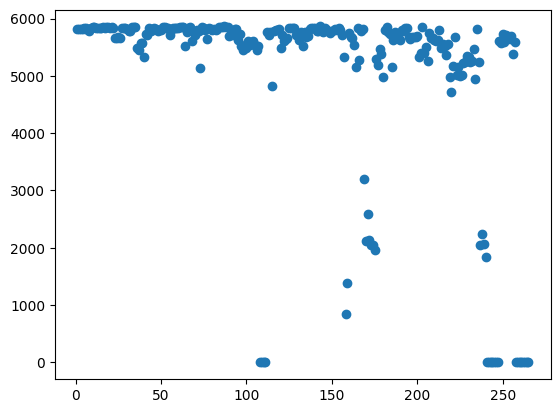

In [25]:
plt.scatter(x = recon_df['#idx'], y = recon_df['n_markers'])

Once you are happy with your inference syngraph tabulate creates the table of marker linkage group membership per node. It is much easier to use this results table for analysis and visualisation than the mostly descriptive/diagnostic plots generated by syngraph infer

In [10]:
!syngraph tabulate -g data/syngraph_run/hymenoptera.mindist.m50.syngraph_infer.with_ancestors.pickle -o data/syngraph_run/hymenoptera.syngraph_tabulate

[+] Sorting out commandline arguments ...
[+] Creating Syngraph from file ...
[+] Show Syngraph metrics ...
[=] ====================================
[=] Taxa = 533
[=] Nodes (Markers) = 5919
[=] Nodes (Markers) shared by > 1 taxon = 5919
[=] Nodes (Markers) shared by all taxa = 0
[=] Distinct Edges (Adjacencies) = 157850
[=] Subgraphs (connected components) = 1
[=] ====================================
[*] Total runtime: 10.614s


First we can split the output table into files which tell us what linkage groups are at each node

In [11]:
def get_node_tables(syngraph_tabulate_table):

    df = pd.read_csv(syngraph_tabulate_table, sep='\t', low_memory=False)
    node_pattern = r'n\d*_seq'
    node_columns = [column for column in df.columns if re.search(node_pattern, column)]

    if not os.path.exists('node_tables'):
        os.makedirs('node_tables')
        
    for node in node_columns:
        node_df = df[['#marker', node]].dropna()
        node_df.to_csv(f'node_tables/{node}.table.tsv', sep='\t', index=False, header=None)

In [12]:
get_node_tables('data/syngraph_run/hymenoptera.syngraph_tabulate.table.tsv')